In [1]:
import glob
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import genextreme as gev
import cmdline_provenance as cmdprov

from unseen import fileio
from unseen import process_utils
from unseen import eva
from unseen import stability
from unseen import independence
from unseen import bias_correction
from unseen import time_utils
from unseen import general_utils
#from unseen import moments
from unseen import similarity
from unseen import spatial_selection

In [2]:
code_url = 'https://github.com/AusClimateService/unseen-projects/tree/master/project-wcrp-txx'
model = 'CanESM5'
var = 'tasmax'
var_levels = np.arange(0, 51, 5)
var_cmap = 'hot_r'
metric = 'TXx'
metric_long = 'hottest day of the year'
units = 'degC'
baseline_period = ['1970-01-01', '2017-12-30'] 
correction_method = 'additive'

region_name = 'NorthAmerica'
region_lat0 = 30  #30N
region_lat1 = 70  #70N
region_lon0 = 180 #180W
region_lon1 = 300 #60W

#map_proj = ccrs.PlateCarree(central_longitude=180)
map_proj = ccrs.LambertConformal(
    central_longitude=240,
    central_latitude=50,
)

box_name = 'PNW heatwave region'
box_lat0 = 45
box_lat1 = 52
box_lon0 = 237
box_lon1 = 241

dist_min = 25
dist_max = 40

outdir = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data'
obs_file = f'{outdir}/txx_ERA5_1940-2025_annual_PNW.nc'
model_file = f'{outdir}/txx_CanESM5-dcppA-hindcast_196101-201701_annual_PNW.nc'

In [3]:
baseline_start = baseline_period[0][0:4]
baseline_end = baseline_period[1][0:4]

In [35]:
def get_encoding(ds, var):
    """Output file encoding."""

    encoding = {}
    ds_vars = list(ds.coords) + list(ds.keys())
    for ds_var in ds_vars:
        encoding[ds_var] = {'_FillValue': None}

    return encoding

In [5]:
def likelihood(data, event):
    """Calculate event likelihood"""

    shape, loc, scale = eva.fit_gev(data)
    probability = gev.sf(event, shape, loc=loc, scale=scale)
    return_period = 1. / probability
    percentile = (1 - probability) * 100
    print(f'{return_period:.0f} year return period')
    print(f'{percentile:.2f}% percentile')

    return shape, loc, scale

## Read observations

In [6]:
obs_ds = fileio.open_dataset(obs_file)
obs_ds = obs_ds.dropna("time")

In [7]:
obs_max_event = obs_ds[var].values.max()
print(obs_max_event)

39.51474681653524


In [8]:
obs_ds_baseline = time_utils.select_time_period(obs_ds, baseline_period)

## Read (and test) model data

In [9]:
model_ds = fileio.open_dataset(model_file)

In [10]:
model_ds = model_ds.compute()
model_ds

<xarray.Dataset> Size: 552kB
Dimensions:     (init_date: 57, ensemble: 20, lead_time: 10)
Coordinates:
    event_time  (init_date, ensemble, lead_time) <U10 456kB '1961-09-19' ... ...
  * ensemble    (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
  * lead_time   (lead_time) int64 80B 0 1 2 3 4 5 6 7 8 9
  * init_date   (init_date) object 456B 1961-01-01 00:00:00 ... 2017-01-01 00...
    time        (lead_time, init_date) object 5kB 1961-01-01 00:00:00 ... 202...
Data variables:
    tasmax      (init_date, ensemble, lead_time) float64 91kB 29.43 ... 33.45
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          d2a-asm-e01
    CCCma_pycmor_hash:           13db8596c37129e414cad7ae31f2927ca8f5dd39
    CCCma_runid:                 d2a196101e01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1961:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/25f98021-2584-4a17-9c4d-f9aa8aa...
    variable_id:                 tasmax
    variant_label:               r1i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

#### Stability and stationarity

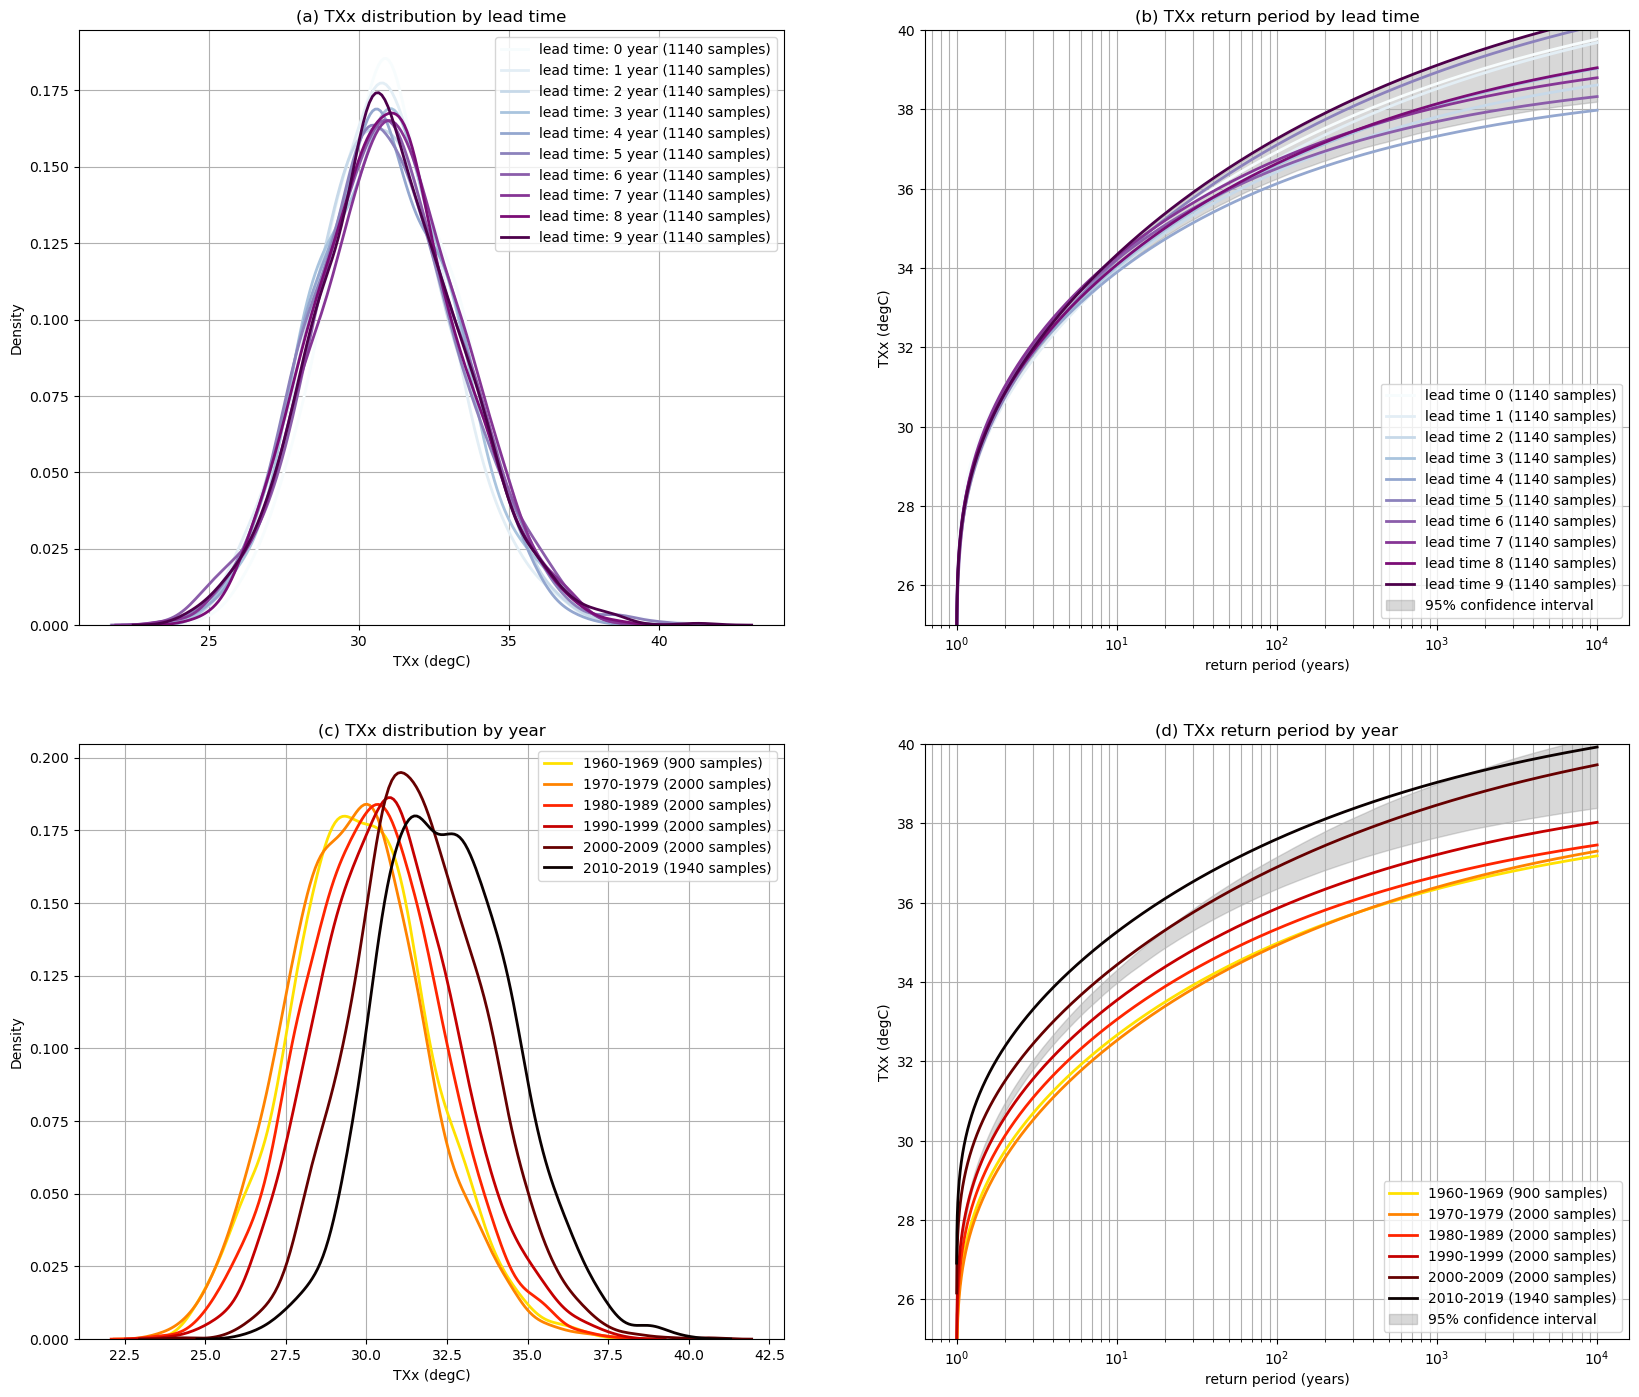

In [11]:
stability.create_plot(
    model_ds[var],
    metric,
    [1960, 1970, 1980, 1990, 2000, 2010],
    uncertainty=True,
    return_method='gev',
    units=f'{metric} ({units})',
    ylim=(dist_min, dist_max),
)

#### Independence

In [12]:
independence_ds = independence.run_tests(model_ds[var])

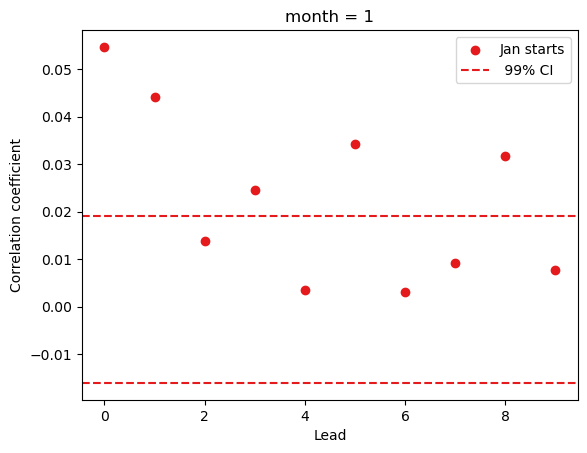

In [13]:
independence.point_plot(
    independence_ds,
    confidence_interval=0.99,
)

In [14]:
min_lead = 2

Drop lead times that aren't independent...

In [15]:
model_da_indep = model_ds[var].where(model_ds['lead_time'] >= min_lead)
model_da_indep = model_da_indep.dropna('lead_time')

In [16]:
model_da_indep_stacked = model_da_indep.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [17]:
model_da_indep_baseline = time_utils.select_time_period(model_da_indep, baseline_period)
model_da_indep_baseline_stacked = model_da_indep_baseline.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

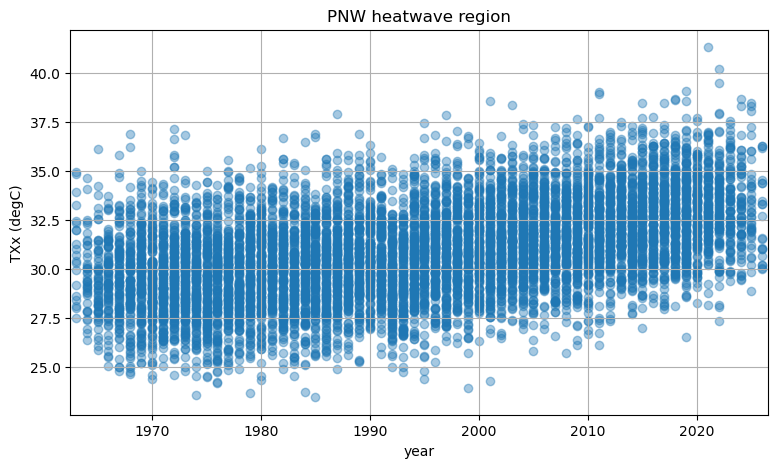

In [18]:
fig, ax = plt.subplots(figsize=[9, 5])
years = model_da_indep_stacked['time'].dt.year.values
unique_years = np.unique(model_da_indep_stacked.time.dt.year.values)

plt.scatter(
    years,
    model_da_indep_stacked.values,
    marker='o',
    color='tab:blue',
    alpha=0.4,
    label='raw data'
)
plt.xlim(unique_years[0] - 0.5, unique_years[-1] + 0.5)
plt.title(box_name)
plt.ylabel(f'{metric} ({units})')
plt.xlabel('year')
#plt.legend()
plt.grid()
plt.show()

#### Bias correction

In [19]:
bias = bias_correction.get_bias(
    model_da_indep,
    obs_ds[var],
    correction_method,
    time_rounding='A',
    time_period=baseline_period
)
print(bias)

<xarray.DataArray 'tasmax' (month: 1)> Size: 8B
dask.array<subtract, shape=(1,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 8B 1
Attributes:
    standard_name:           air_temperature
    long_name:               Daily Maximum Near-Surface Air Temperature
    comment:                 maximum near-surface (usually, 2 meter) air temp...
    units:                   °C
    original_name:           STMX
    cell_methods:            area: mean time: maximum
    cell_measures:           area: areacella
    history:                 2019-06-18T21:25:55Z altered by CMOR: Treated sc...
    units_metadata:          temperature: unknown
    climatological_period:   ['1970-01-01', '2017-12-30']
    bias_correction_method:  additive
    bias_correction_period:  1970-01-01-2017-12-30


In [20]:
bias.values

array([-0.06089068])

In [21]:
model_da_bc = bias_correction.remove_bias(model_da_indep, bias, correction_method)

In [22]:
model_da_bc = model_da_bc.compute()

In [23]:
model_da_bc_stacked = model_da_bc.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [24]:
model_da_bc_baseline = time_utils.select_time_period(model_da_bc, baseline_period)
model_da_bc_baseline_stacked = model_da_bc_baseline.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

#### Similarity testing

In [25]:
def plot_dist(time_period='full'):
    """Plot distribution."""

    assert time_period in ['full', 'baseline']

    fig, ax = plt.subplots(figsize=[8, 5])
    xvals = np.arange(dist_min, dist_max, 0.1)

    if time_period == 'baseline':
        title = f'{box_name} - comparison period ({baseline_start}-{baseline_end})'
        model_da_indep_baseline.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
        model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_baseline_stacked.values)
        model_da_bc_baseline.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
        model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_baseline_stacked.values)
        obs_ds_baseline[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
        obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_ds_baseline[var].values)
    else:
        title = f'{box_name} - full timeseries'
        model_da_indep.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
        model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_stacked.values)
        model_da_bc.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
        model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_stacked.values)
        obs_ds[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
        obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_ds[var].values)
    
    model_raw_pdf = gev.pdf(xvals, model_raw_shape, model_raw_loc, model_raw_scale)
    plt.plot(xvals, model_raw_pdf, color='tab:blue', linewidth=4.0, label='model')
    
    model_bc_pdf = gev.pdf(xvals, model_bc_shape, model_bc_loc, model_bc_scale)
    plt.plot(xvals, model_bc_pdf, color='tab:orange', linewidth=4.0, label='model (corrected)')
    
    obs_pdf = gev.pdf(xvals, obs_shape, obs_loc, obs_scale)
    plt.plot(xvals, obs_pdf, color='tab:gray', linewidth=4.0, label='ERA5')
    
    plt.xlabel(f'{metric} ({units})')
    plt.ylabel('probability')
    plt.title(title)
    plt.xlim(dist_min, dist_max)
    plt.legend()
    plt.grid()
    plt.show()

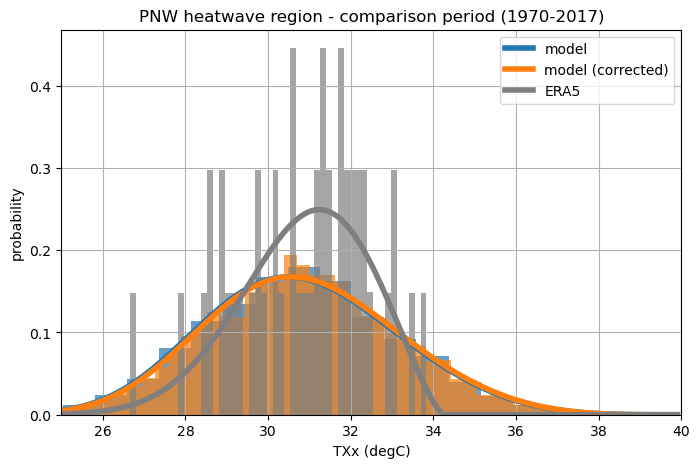

In [26]:
plot_dist(time_period='baseline')

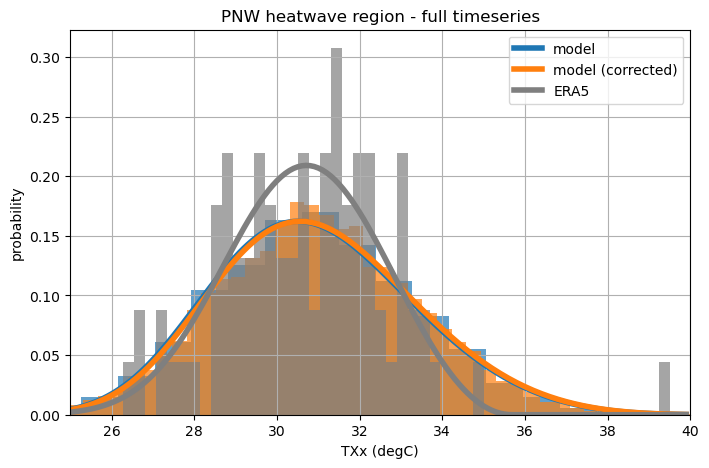

In [27]:
plot_dist(time_period='full')

Since the data has a strong trend with time, the similarity testing is conducted over the time period equally sampled by the observations and model (1970-2017).

In [28]:
#moments.create_plot(
#    model_da_indep_baseline,
#    obs_ds_baseline[var],
#    da_bc_fcst=model_da_bc_baseline,
#)

In [29]:
similarity_ds = similarity.similarity_tests(model_da_indep_baseline, obs_ds_baseline[var])
print('KS score:', similarity_ds['ks_statistic'].values)
print('KS p-value:', similarity_ds['ks_pval'].values)
print('AD score:', similarity_ds['ad_statistic'].values)
print('AD p-value:', similarity_ds['ad_pval'].values)

KS score: 0.12645723
KS p-value: 0.4096418
AD score: 1.0113003
AD p-value: 0.12508291


p > 0.05 means that the null hypothesis (that the two samples are from the same population) cannot be rejected.

#### Process assessment

In [30]:
def ensemble_to_run(model_name, ensnum):
    """Map ensemble number to DCPP model run"""

    ensemble_to_run = {   
        'CanESM5': f'r{ensnum}i1p2f1',
        'CMCC-CM2-SR5': f'r{ensnum}i1p1f1',
        'EC-Earth3': f'r{ensnum}i1p1f1' if ensnum <= 10 else f'r{ensnum-5}i2p1f1',
        'HadGEM3-GC31-MM': f'r{ensnum}i1p1f2',
        'IPSL-CM6A-LR': f'r{ensnum}i1p1f1',
        'MIROC6': f'r{ensnum}i1p1f1',
        'MPI-ESM1-2-HR': f'r{ensnum}i1p1f1',
        'MRI-ESM2-0': f'r{ensnum}i1p1f1',
        'NorCPM1': f'r{ensnum}i1p1f1' if ensnum <= 10 else f'r{ensnum-10}i2p1f1'
    }
    run = ensemble_to_run[model_name]

    return run
    

def find_dcpp_data(event_df_row, model_name):
    """Find DCPP data for one row of a dataframe of events."""

    init_adjustment = {
        'CanESM5': -1,
        'CMCC-CM2-SR5': 0,
        'EC-Earth3': 0,
        'HadGEM3-GC31-MM': 0,
        'IPSL-CM6A-LR': -1,
        'MIROC6': 0,
        'MPI-ESM1-2-HR': 0,
        'MRI-ESM2-0': 0,
        'NorCPM1': 0,
    }

    assert model_name in init_adjustment
    
    init_date = int(event_df_row['init_date'].strftime('%Y')) + init_adjustment[model_name]
    ensemble = int(event_df_row['ensemble']) + 1
    run = ensemble_to_run(model_name, ensemble)
    event_date = event_df_row['event_time']
    event_value = round(float(event_df_row[var]), 1)
    event_summary = f'{metric} of {event_value} on {event_date}: initialisation year {init_date}, ensemble member {run}'
    print(event_summary)
    var_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/day/{var}/*/*/*.nc')
    assert len(var_files) == 1
    psl_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/day/psl/*/*/*.nc')
    assert len(psl_files) == 1
        
    return var_files[0], psl_files[0], event_date, event_value, event_summary

In [51]:
def event_check(da, event_value):
    """Check the event value"""

    da_box = da.sel(lat=slice(box_lat0, box_lat1), lon=slice(box_lon0, box_lon1))
    da_box_mean = spatial_selection.aggregate(da_box, 'weighted_mean')

    np.testing.assert_approx_equal(float(da_box_mean[-1]), event_value, significant=1)
    

def get_start_date(event_date):
    """Get start date."""

    event_datetime = datetime.strptime(event_date, "%Y-%m-%d")
    start_datetime = event_datetime - timedelta(days=4)
    start_date = start_datetime.strftime("%Y-%m-%d")

    return start_date


def to_file_date(selected_date):
    """Convert a YYYY-MM-DD date to YYYYMMDD"""

    selected_datetime = datetime.strptime(selected_date, "%Y-%m-%d")
    selected_filedate = selected_datetime.strftime("%Y%m%d")

    return selected_filedate


def get_outfname(inpath, start_date, end_date):
    """Get output file name."""

    start_filedate = to_file_date(start_date)
    end_filedate = to_file_date(end_date)

    infname = inpath.split('/')[-1]
    fparts = infname.split('_')
    fparts[-1] = f'{start_filedate}-{end_filedate}.nc'
    fparts[-2] = f'{fparts[-2]}-{region_name}'
    outfname = '_'.join(fparts)
    outpath = f'{outdir}/{outfname}'

    return outpath


def thin_attrs(ds, var, unit):
    """Thin the variable attributes"""

    try:
        ds = ds.drop_vars('height')
    except ValueError:
        pass
    
    orig_attrs = ds[var].attrs
    ds[var].attrs = {}
    ds[var].attrs['long_name'] = orig_attrs['long_name']
    ds[var].attrs['standard_name'] = orig_attrs['standard_name']
    ds[var].attrs['units'] = unit

    return ds


def get_event_data(event_df_row, model_name, write_to_file=False):
    """Plot an event"""

    infile_var, infile_psl, event_date, event_value, event_summary = find_dcpp_data(event_df_row, model_name)

    start_date = get_start_date(event_date)

    ds_var = fileio.open_dataset(infile_var)
    ds_var = ds_var.sel(
        time=slice(start_date, event_date),
        lat=slice(region_lat0 - 5, region_lat1 + 5),
        lon=slice(region_lon0 - 5, region_lon1 + 5),
    )
    da_var = general_utils.convert_units(ds_var[var], units)
    event_check(da_var, event_value)
    
    ds_psl = fileio.open_dataset(infile_psl)
    ds_psl = ds_psl.sel(
        time=slice(start_date, event_date),
        lat=slice(region_lat0 - 5, region_lat1 + 5),
        lon=slice(region_lon0 - 5, region_lon1 + 5),
    )
    da_psl = general_utils.convert_units(ds_psl['psl'], 'hPa')

    if write_to_file:
        output_ds_var = da_var.to_dataset()
        output_ds_var = thin_attrs(output_ds_var, var, units)
        output_ds_var.attrs = {
            'description': f'Five days leading up to and including this event - {event_summary}',
            'model': model,
            'history': cmdprov.new_log(code_url=code_url),
        }
        fname_var = get_outfname(infile_var, start_date, event_date)
        encoding = get_encoding(output_ds_var, var)
        output_ds_var.to_netcdf(fname_var, encoding=encoding)
        print(fname_var)

        output_ds_psl = da_psl.to_dataset()
        output_ds_psl = thin_attrs(output_ds_psl, 'psl', 'hPa')
        output_ds_psl.attrs = {
            'description': f'Five days leading up to and including this event - {event_summary}',
            'model': model,
            'history': cmdprov.new_log(code_url=code_url),
        }
        fname_psl = get_outfname(infile_psl, start_date, event_date)
        encoding = get_encoding(output_ds_psl, 'psl')
        output_ds_psl.to_netcdf(fname_psl, encoding=encoding)
        print(fname_psl)

    return da_var, da_psl

In [49]:
def plot_event(da_var, da_psl):
    """Plot event."""

    fig = plt.figure(figsize=[15, 5])
    ax = fig.add_subplot(111, projection=map_proj)
    
    da_var.isel(time=4).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=var_cmap,
        levels=var_levels,
        extend='both',
    #    cbar_kwargs={"label": label},
    )
    lines = da_psl.isel(time=4).plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=np.arange(900, 1100, 3),
        colors=["0.3"]
    )
    ax.clabel(lines, colors=["0.3"], manual=False, inline=True)
    
    ax.plot(
        [box_lon0, box_lon0, box_lon1, box_lon1, box_lon0],
        [box_lat1, box_lat0, box_lat0, box_lat1, box_lat1],
        transform=ccrs.PlateCarree(),
        color='green',
    )   
    ax.coastlines()
    #ax.set_extent([180, 300, 30, 70], crs=ccrs.PlateCarree(central_longitude=0))
    ax.add_feature(cartopy.feature.BORDERS)
    ax.gridlines(linestyle="--", draw_labels=True)
    
    plt.show()

In [33]:
model_da_bc_stacked_df = model_da_bc_stacked.to_dataframe()
model_da_bc_stacked_df_sorted = model_da_bc_stacked_df.sort_values(by=[var], ascending=False)
model_da_bc_stacked_df_sorted.head(n=5)

,,,event_time,time,ensemble,init_date,lead_time,tasmax
ensemble,init_date,lead_time,,,,,,
10,2012-01-01 00:00:00,9,2021-08-09,2021-01-01 00:00:00,10,2012-01-01 00:00:00,9,41.358087
8,2017-01-01 00:00:00,5,2022-07-19,2022-01-01 00:00:00,8,2017-01-01 00:00:00,5,40.241957
3,2017-01-01 00:00:00,5,2022-08-07,2022-01-01 00:00:00,3,2017-01-01 00:00:00,5,39.522106
2,2012-01-01 00:00:00,7,2019-07-28,2019-01-01 00:00:00,2,2012-01-01 00:00:00,7,39.119254
9,2008-01-01 00:00:00,3,2011-08-24,2011-01-01 00:00:00,9,2008-01-01 00:00:00,3,39.095764


TXx of 41.4 on 2021-08-09: initialisation year 2011, ensemble member r11i1p2f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_CanESM5_dcppA-hindcast_s2011-r11i1p2f1_gn-NorthAmerica_20210805-20210809.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_CanESM5_dcppA-hindcast_s2011-r11i1p2f1_gn-NorthAmerica_20210805-20210809.nc


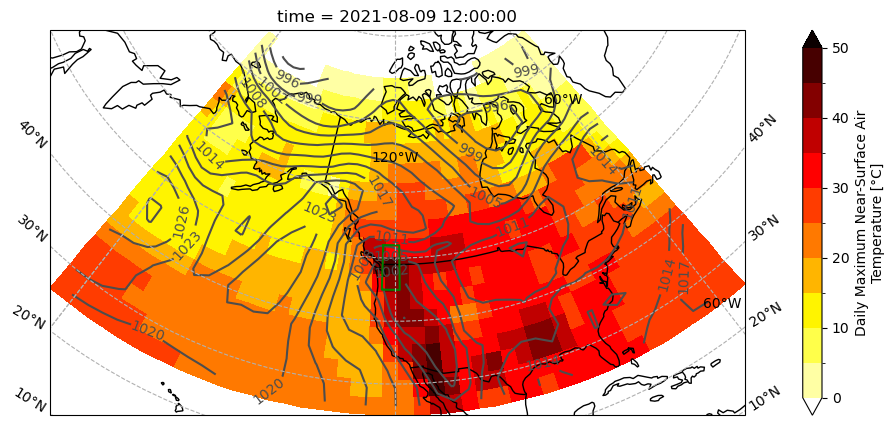

TXx of 40.2 on 2022-07-19: initialisation year 2016, ensemble member r9i1p2f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_CanESM5_dcppA-hindcast_s2016-r9i1p2f1_gn-NorthAmerica_20220715-20220719.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_CanESM5_dcppA-hindcast_s2016-r9i1p2f1_gn-NorthAmerica_20220715-20220719.nc


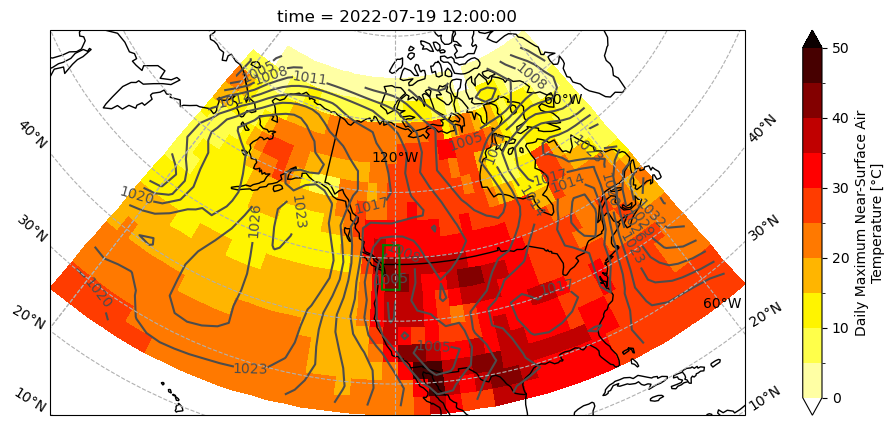

TXx of 39.5 on 2022-08-07: initialisation year 2016, ensemble member r4i1p2f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_CanESM5_dcppA-hindcast_s2016-r4i1p2f1_gn-NorthAmerica_20220803-20220807.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_CanESM5_dcppA-hindcast_s2016-r4i1p2f1_gn-NorthAmerica_20220803-20220807.nc


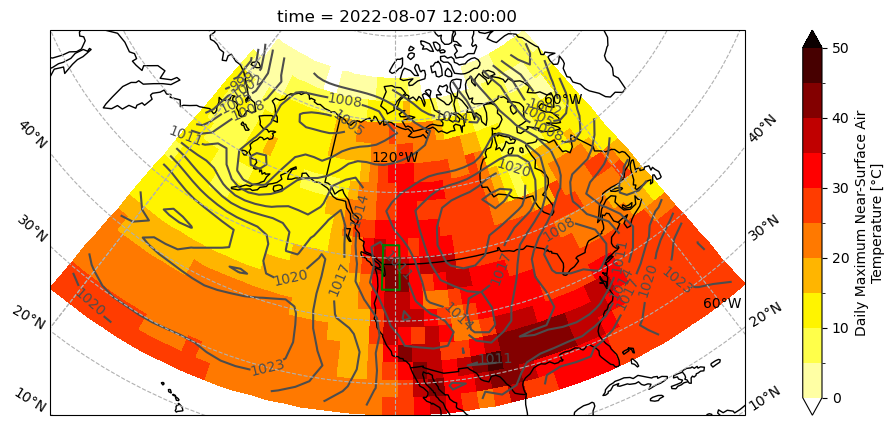

TXx of 39.1 on 2019-07-28: initialisation year 2011, ensemble member r3i1p2f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_CanESM5_dcppA-hindcast_s2011-r3i1p2f1_gn-NorthAmerica_20190724-20190728.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_CanESM5_dcppA-hindcast_s2011-r3i1p2f1_gn-NorthAmerica_20190724-20190728.nc


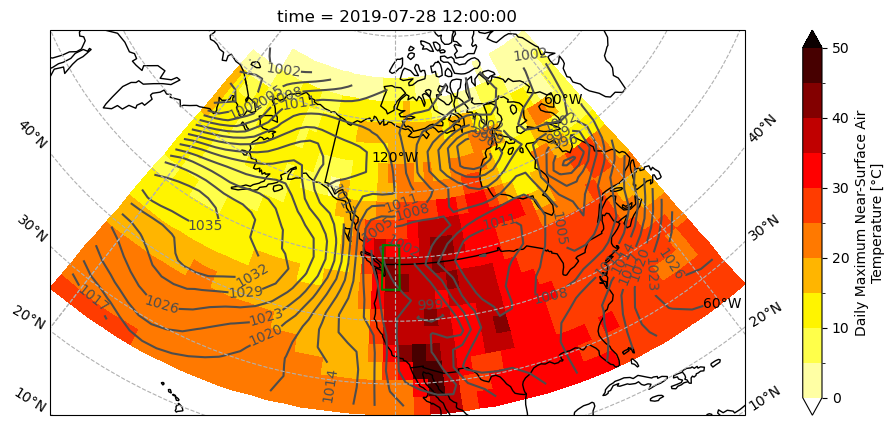

TXx of 39.1 on 2011-08-24: initialisation year 2007, ensemble member r10i1p2f1
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax_day_CanESM5_dcppA-hindcast_s2007-r10i1p2f1_gn-NorthAmerica_20110820-20110824.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl_day_CanESM5_dcppA-hindcast_s2007-r10i1p2f1_gn-NorthAmerica_20110820-20110824.nc


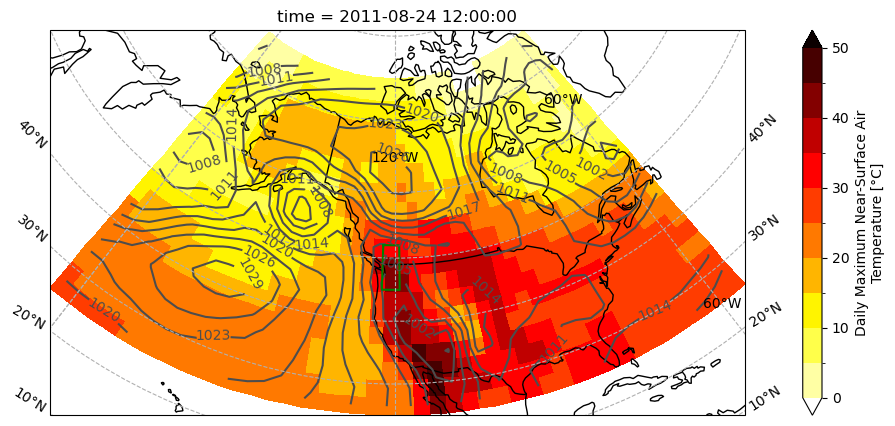

In [52]:
for event in range(5):
    da_var, da_psl = get_event_data(
        model_da_bc_stacked_df_sorted.iloc[event],
        model,
        write_to_file=True
    )
    plot_event(da_var, da_psl)

## Results

In [39]:
def write_samples(input_da, model, dtype):
    """Write samples to file."""

    assert dtype in ['bias corrected', 'raw']
    
    nsamples = len(input_da)
    numbers = list(np.arange(nsamples) + 1)
    output_da = xr.DataArray(
        data=np.round(input_da.values, 2),
        coords={'number': numbers,},
        name=metric,
        attrs = {
            'long_name': metric_long,
            'units': units,
        }
    )
    output_ds = output_da.to_dataset()
    output_ds.attrs = {
        'description': f'{dtype} samples',
        'model': model,
        'history': cmdprov.new_log(code_url=code_url),
    }
    
    fname_dtype = dtype.replace(' ', '-')
    fname = f'{outdir}/{metric.lower()}_{model}_{fname_dtype}.nc'
    encoding = get_encoding(output_ds, metric)
    output_ds.to_netcdf(fname, encoding=encoding)
    print(fname)

In [40]:
write_samples(model_da_bc_stacked, model, 'bias corrected')

/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/txx_CanESM5_bias-corrected.nc


In [41]:
write_samples(model_da_indep_stacked, model, 'raw')

/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/txx_CanESM5_raw.nc


#### Non-stationary GEV

In [42]:
#AIC/BIC/LRT test to see if it's worth modelling the scale trend
daparams_list = [eva.fit_gev(
    model_da_bc_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_bc_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=scale1,
).values for scale1 in [0, None]]

data = model_da_bc_stacked.values
covariate = model_da_bc_stacked['time'].dt.year.values
nll_1 = eva._gev_nllf(daparams_list[0], data, covariate)
nll_2 = eva._gev_nllf(daparams_list[1], data, covariate)
result = eva.check_gev_relative_fit(data, nll_1, nll_2, test='bic', n_params=[4,5])
print('better to include the scale trend parameter:', result)

better to include the scale trend parameter: False


In [43]:
daparams = eva.fit_gev(
    model_da_bc_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_bc_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=None,
)

In [44]:
for param, value in zip(daparams.dparams.values, daparams.values):
    print(param, value)

c 0.20915858545959512
location_0 -109.0767242652463
location_1 0.06982080545908281
scale_0 2.035222751571741
scale_1 0.0


In [45]:
return_period = float(eva.get_return_period(obs_max_event, daparams, covariate=2021).values)

In [46]:
print(f'The return period of a {obs_max_event:.2f} {units} event in 2021 is {return_period:.0f} years.')

The return period of a 39.51 degC event in 2021 is 1106 years.


In [47]:
for year in np.arange(1960, 2030):
    rp = float(eva.get_return_period(obs_max_event, daparams, covariate=year).values)
    print(f'The return period of a {obs_max_event:.2f} {units} event in {year} is {rp:.0f} years.')

The return period of a 39.51 degC event in 1960 is inf years.
The return period of a 39.51 degC event in 1961 is inf years.
The return period of a 39.51 degC event in 1962 is inf years.
The return period of a 39.51 degC event in 1963 is inf years.
The return period of a 39.51 degC event in 1964 is inf years.
The return period of a 39.51 degC event in 1965 is inf years.
The return period of a 39.51 degC event in 1966 is inf years.
The return period of a 39.51 degC event in 1967 is inf years.
The return period of a 39.51 degC event in 1968 is inf years.
The return period of a 39.51 degC event in 1969 is inf years.
The return period of a 39.51 degC event in 1970 is inf years.
The return period of a 39.51 degC event in 1971 is inf years.
The return period of a 39.51 degC event in 1972 is inf years.
The return period of a 39.51 degC event in 1973 is inf years.
The return period of a 39.51 degC event in 1974 is inf years.
The return period of a 39.51 degC event in 1975 is inf years.
The retu